# Cluster selection and cleaned reconstruction

Stage 2 for the V2a workflow. This notebook loads decomposition artifacts from `decompositions.ipynb`, applies the shared model-benchmark component-selection implementations, reconstructs cleaned traces, and saves auditable outputs plus figures.

The full-recording selections here are descriptive and artifact-preparation outputs. Leakage-safe behavior and causal evidence remain the responsibility of the fold-local evaluation runner.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")

from ica_denoising.behavior_decoding import TraceVariant, summarize_trace_preservation
from ica_denoising.bss_notebook import (
    BSS_METHODS,
    load_bss_decomposition_outputs,
    load_traces,
    save_cleaned_trace_output,
    save_cluster_selection_output,
)
from ica_denoising.evaluation_pipeline import (
    FittedBSSModel,
    fit_cluster_selection,
    ic_quality_table_for_bss_model,
    select_components,
    select_components_by_ic_quality,
)


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


In [2]:
DATASET_KEY = "v2a-RSNs/220119_F2_run11_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS)
N_CLUSTERS = 7
FEATURE_START_BIN = 30
FEATURE_TRANSFORM = "log1p"
WELCH_NPERSEG = 250
WELCH_NOVERLAP = 125
RANKING_FMIN_HZ = 0.0
RANKING_FMAX_HZ = 0.20
RANKING_AGGREGATE = "peak"
KEEP_TOP_CLUSTER_COUNT = 2
IC_QUALITY_SELECTION_STRATEGIES = ("ic_quality_nonartifact", "ic_quality_strict_keep")
RANDOM_STATE = 0
PLOT_DPI = 300
SAVE_OUTPUTS = True


In [3]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
sample_rate_hz = float(dataset.sample_rate_hz)
results = {}
skipped = {}
for method in METHODS_TO_RUN:
    try:
        results[method] = load_bss_decomposition_outputs(
            DATASET_KEY,
            method,
            PROJECT_ROOT,
            output_data_name_override=OUTPUT_DATA_NAME,
        )
    except FileNotFoundError as error:
        skipped[method] = str(error).splitlines()[0]

if not results:
    raise FileNotFoundError("No saved decompositions found. Run decompositions.ipynb first.")
dataset_output_dir = next(iter(results.values())).output_dir.parent
figure_dir = dataset_output_dir / "figures"
if SAVE_OUTPUTS:
    figure_dir.mkdir(parents=True, exist_ok=True)
print(f"Dataset: {dataset.key}")
print(f"Loaded methods: {list(results)}")
print(f"Skipped methods: {skipped}")
print(f"Dataset output directory: {dataset_output_dir.relative_to(PROJECT_ROOT)}")


Dataset: v2a-RSNs/220119_F2_run11_fluorescence
Loaded methods: ['fastica', 'infomax', 'sobi', 'jade']
Skipped methods: {}
Dataset output directory: outputs/linear/v2a-RSNs/220119_F2_run11


In [4]:
def as_full_recording_bss_model(result):
    n_frames = result.ic_comps.shape[0]
    n_components = result.n_components or result.ic_comps.shape[1]
    return FittedBSSModel(
        method=result.method,
        mean=np.asarray(result.mean, dtype=float),
        mixing=np.asarray(result.A, dtype=float),
        unmixing=np.linalg.pinv(np.asarray(result.A, dtype=float)),
        train_components=np.asarray(result.ic_comps, dtype=float),
        train_idx=np.arange(n_frames, dtype=int),
        train_segment_lengths=(int(n_frames),),
        n_components=int(n_components),
        pca_components=result.pca_components,
        pca_variance_threshold=result.pca_variance_threshold,
        pca_explained_variance_ratio=result.pca_explained_variance_ratio,
        component_selection_mode=result.component_selection_mode or "saved_decomposition",
    )


def cluster_scores(selection):
    freqs = np.linspace(0.0, sample_rate_hz / 2.0, selection.spectra.shape[1])
    band = (freqs >= RANKING_FMIN_HZ) & (freqs <= RANKING_FMAX_HZ)
    if not np.any(band):
        band = np.ones(freqs.shape, dtype=bool)
    eps = np.finfo(float).eps
    rows = []
    for rank, cluster_id in enumerate(selection.cluster_order, start=1):
        cluster_mask = selection.labels == int(cluster_id)
        mean_log = np.log(np.maximum(selection.spectra[cluster_mask][:, band], eps)).mean(axis=0)
        score = float(np.max(mean_log) if RANKING_AGGREGATE == "peak" else np.mean(mean_log))
        rows.append({"cluster": int(cluster_id), "rank": int(rank), "score": score})
    return rows


models = {method: as_full_recording_bss_model(result) for method, result in results.items()}
cluster_results = {}
quality_tables = {}
ranking_rows = []
component_rows = []
for method, model in models.items():
    selection = fit_cluster_selection(
        model,
        sample_rate_hz=sample_rate_hz,
        n_clusters=N_CLUSTERS,
        feature_start_bin=FEATURE_START_BIN,
        feature_transform=FEATURE_TRANSFORM,
        nperseg=WELCH_NPERSEG,
        noverlap=WELCH_NOVERLAP,
        ranking_fmin_hz=RANKING_FMIN_HZ,
        ranking_fmax_hz=RANKING_FMAX_HZ,
        ranking_aggregate=RANKING_AGGREGATE,
        random_state=RANDOM_STATE,
    )
    quality = ic_quality_table_for_bss_model(
        model,
        sample_rate_hz=sample_rate_hz,
        nperseg=WELCH_NPERSEG,
        noverlap=WELCH_NOVERLAP,
    )
    quality_by_component = quality.set_index("component")
    ranking = cluster_scores(selection)
    rank_by_cluster = {row["cluster"]: row["rank"] for row in ranking}
    score_by_cluster = {row["cluster"]: row["score"] for row in ranking}
    cluster_results[method] = {"selection": selection, "ranking": ranking}
    quality_tables[method] = quality
    for row in ranking:
        ranking_rows.append({"method": method, **row})
    for component, cluster_id in enumerate(selection.labels):
        quality_row = quality_by_component.loc[int(component)]
        component_rows.append(
            {
                "method": method,
                "component": int(component),
                "cluster": int(cluster_id),
                "cluster_rank": int(rank_by_cluster[int(cluster_id)]),
                "cluster_score": float(score_by_cluster[int(cluster_id)]),
                "component_energy": float(selection.component_energy[component]),
                "artifact_score": float(quality_row["artifact_score"]),
                "protect_score": float(quality_row["protect_score"]),
                "recommendation": str(quality_row["recommendation"]),
                "artifact_flags": str(quality_row["artifact_flags"]),
                "protect_flags": str(quality_row["protect_flags"]),
            }
        )
    print(f"{method}: cluster rank order = {list(selection.cluster_order)}")

cluster_ranking = pd.DataFrame(ranking_rows)
component_selection_table = pd.DataFrame(component_rows)
ic_quality_recommendations = pd.concat(
    [table.assign(method=method) for method, table in quality_tables.items()],
    ignore_index=True,
)
cluster_ranking_path = dataset_output_dir / "cluster_ranking.csv"
component_selection_path = dataset_output_dir / "component_selections.csv"
ic_quality_path = dataset_output_dir / "ic_quality_recommendations.csv"
if SAVE_OUTPUTS:
    cluster_ranking.to_csv(cluster_ranking_path, index=False)
    component_selection_table.to_csv(component_selection_path, index=False)
    ic_quality_recommendations.to_csv(ic_quality_path, index=False)
    print(f"Saved cluster ranking: {cluster_ranking_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved component selections: {component_selection_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved IC-quality recommendations: {ic_quality_path.relative_to(PROJECT_ROOT)}")
display(cluster_ranking)


fastica: cluster rank order = [0, 2, 4, 3, 6, 1, 5]
infomax: cluster rank order = [1, 3, 5, 0, 6, 2, 4]
sobi: cluster rank order = [3, 0, 6, 1, 4, 5, 2]
jade: cluster rank order = [3, 2, 1, 4, 5, 6, 0]
Saved cluster ranking: outputs/linear/v2a-RSNs/220119_F2_run11/cluster_ranking.csv
Saved component selections: outputs/linear/v2a-RSNs/220119_F2_run11/component_selections.csv
Saved IC-quality recommendations: outputs/linear/v2a-RSNs/220119_F2_run11/ic_quality_recommendations.csv


,method,cluster,rank,score
0,fastica,0,1,1.096039
1,fastica,2,2,0.703127
2,fastica,4,3,-0.189401
3,fastica,3,4,-0.311804
4,fastica,6,5,-0.447846
5,fastica,1,6,-0.427541
6,fastica,5,7,-0.473380
7,infomax,1,1,1.358871
8,infomax,3,2,0.939062
9,infomax,5,3,0.339104


Saved cluster diagnostics for fastica: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_diagnostics_fastica_220119_F2_run11_fluorescence.png
Saved cluster diagnostics for infomax: outputs/linear/v2a-RSNs/220119_F2_run11/infomax/clusters/cluster_diagnostics_infomax_220119_F2_run11_fluorescence.png
Saved cluster diagnostics for sobi: outputs/linear/v2a-RSNs/220119_F2_run11/sobi/clusters/cluster_diagnostics_sobi_220119_F2_run11_fluorescence.png
Saved cluster diagnostics for jade: outputs/linear/v2a-RSNs/220119_F2_run11/jade/clusters/cluster_diagnostics_jade_220119_F2_run11_fluorescence.png


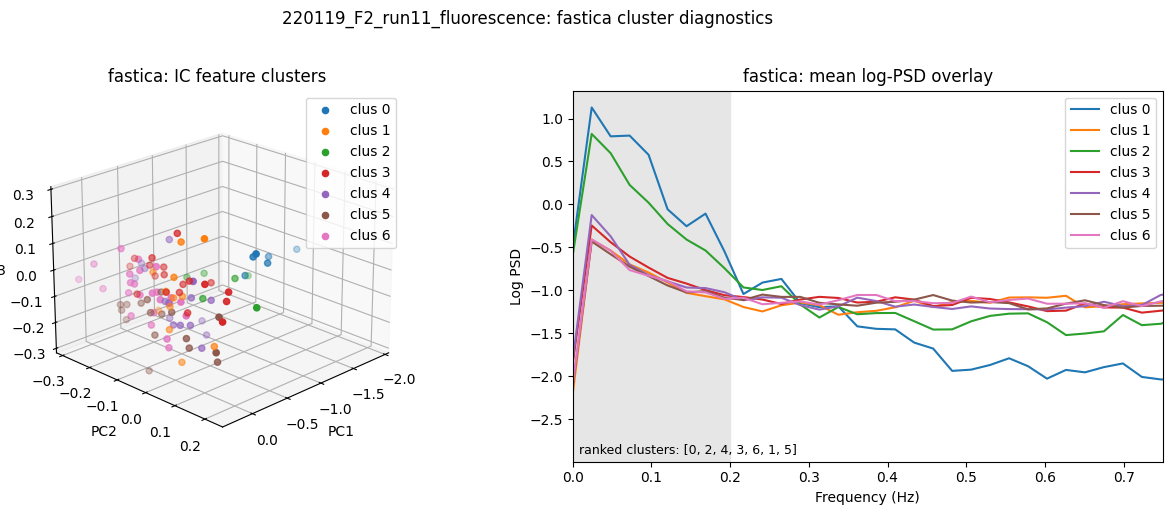

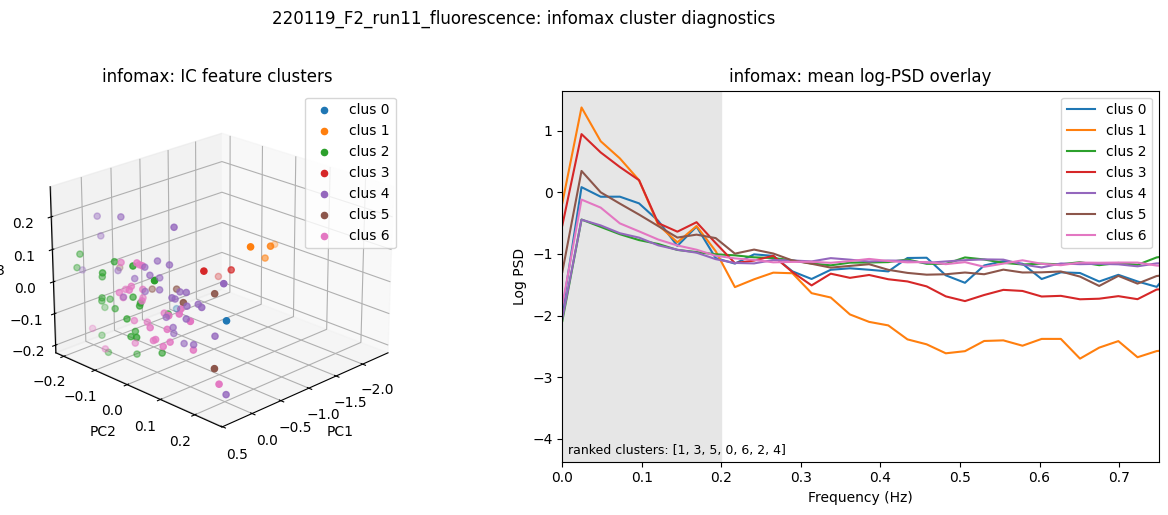

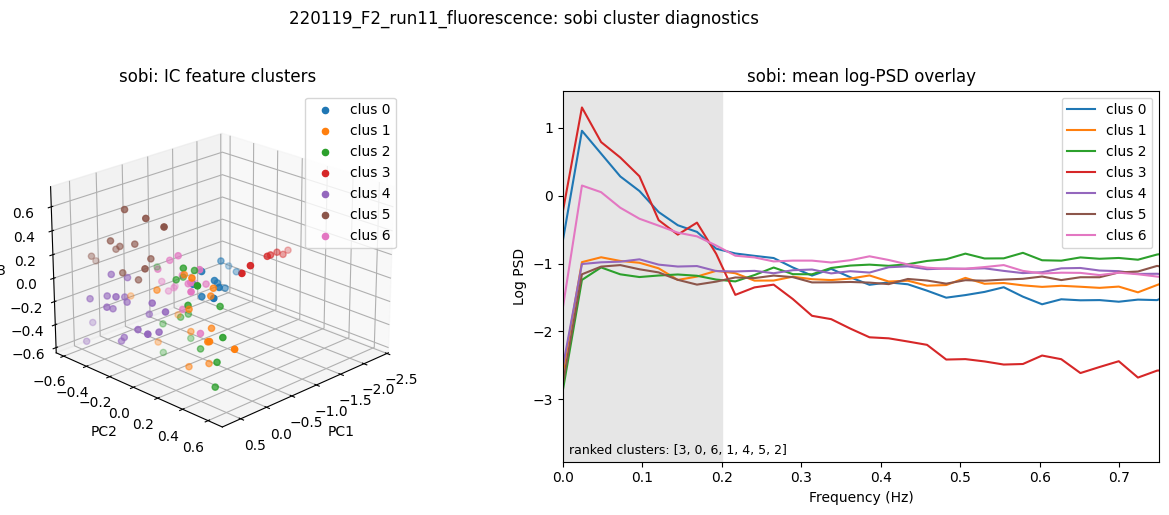

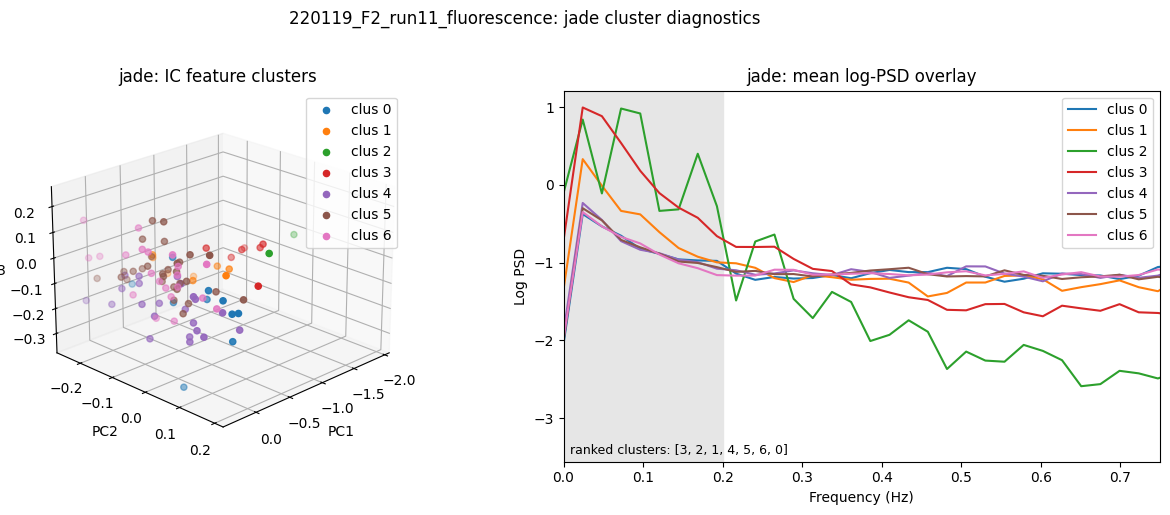

In [5]:
def feature_embedding(features):
    n_components = min(3, features.shape[0], features.shape[1])
    if n_components < 1:
        return np.zeros((features.shape[0], 3), dtype=float)
    embedded = PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(features)
    if embedded.shape[1] < 3:
        embedded = np.column_stack([embedded, np.zeros((embedded.shape[0], 3 - embedded.shape[1]))])
    return embedded


def plot_cluster_diagnostics(method, selection, ranking):
    labels = selection.labels
    spectra = selection.spectra
    embedding = feature_embedding(selection.features)
    rank_order = [row["cluster"] for row in ranking]
    fig = plt.figure(figsize=(13, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.0])

    ax3d = fig.add_subplot(gs[0, 0], projection="3d")
    for label in np.unique(labels):
        points = embedding[labels == label]
        ax3d.scatter(points[:, 0], points[:, 1], points[:, 2], label=f"clus {int(label)}")
    ax3d.set_xlabel("PC1")
    ax3d.set_ylabel("PC2")
    ax3d.set_zlabel("PC3")
    ax3d.set_title(f"{method}: IC feature clusters")
    ax3d.legend(loc="best")
    ax3d.view_init(elev=22, azim=45)

    ax_psd = fig.add_subplot(gs[0, 1])
    eps = np.finfo(float).eps
    freqs = np.linspace(0.0, sample_rate_hz / 2.0, spectra.shape[1])
    for label in np.unique(labels):
        group = spectra[labels == label]
        mean_log = np.log(np.maximum(group.mean(axis=0), eps))
        ax_psd.plot(freqs, mean_log, lw=1.5, label=f"clus {int(label)}")
    ax_psd.axvspan(RANKING_FMIN_HZ, RANKING_FMAX_HZ, color="0.9", zorder=-1)
    ax_psd.set_xlim([0.0, min(0.75, sample_rate_hz / 2.0)])
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("Log PSD")
    ax_psd.set_title(f"{method}: mean log-PSD overlay")
    ax_psd.text(
        0.01,
        0.02,
        f"ranked clusters: {rank_order}",
        transform=ax_psd.transAxes,
        fontsize=9,
    )
    ax_psd.legend(loc="best")

    fig.suptitle(f"{dataset.data_name}: {method} cluster diagnostics", y=1.02)
    fig.tight_layout()
    return fig


figure_paths = {}
for method, clustered in cluster_results.items():
    result = results[method]
    method_cluster_dir = result.output_dir / "clusters"
    if SAVE_OUTPUTS:
        method_cluster_dir.mkdir(parents=True, exist_ok=True)
    stem = f"{method}_{dataset.data_name}"
    fig = plot_cluster_diagnostics(method, clustered["selection"], clustered["ranking"])
    diagnostics_path = method_cluster_dir / f"cluster_diagnostics_{stem}.png"
    manuscript_diagnostics_path = figure_dir / f"cluster_diagnostics_{stem}.png"
    if SAVE_OUTPUTS:
        fig.savefig(diagnostics_path, dpi=PLOT_DPI, bbox_inches="tight")
        fig.savefig(manuscript_diagnostics_path, dpi=PLOT_DPI, bbox_inches="tight")
        print(f"Saved cluster diagnostics for {method}: {diagnostics_path.relative_to(PROJECT_ROOT)}")
    figure_paths[method] = {
        "cluster_diagnostics": diagnostics_path,
        "cluster_diagnostics_manuscript": manuscript_diagnostics_path,
    }


In [6]:
cleaned_variants = {}
selection_summary_rows = []
saved_paths_by_method = {}
primary_selection_by_method = {}

for method, model in models.items():
    result = results[method]
    selection = cluster_results[method]["selection"]
    labels = selection.labels
    all_components = np.arange(labels.size, dtype=int)
    cleaned_variants[method] = {}
    saved_paths_by_method[method] = {}

    max_keep_count = len(selection.cluster_order)
    if max_keep_count > 1:
        max_keep_count -= 1
    cluster_keep_counts = tuple(range(1, max_keep_count + 1))
    primary_selection_id = f"cluster_keep_top_{min(KEEP_TOP_CLUSTER_COUNT, max_keep_count):02d}"
    primary_selection_by_method[method] = primary_selection_id

    selection_specs = []
    for keep_count in cluster_keep_counts:
        keep_components = select_components(
            selection,
            strategy="low_frequency",
            keep_cluster_count=keep_count,
            random_state=RANDOM_STATE,
        )
        keep_clusters = [int(value) for value in selection.cluster_order[:keep_count]]
        selection_specs.append(
            {
                "selection_id": f"cluster_keep_top_{keep_count:02d}",
                "selection_source": "spectral_cluster_rank",
                "keep_cluster_count": int(keep_count),
                "keep_clusters": keep_clusters,
                "keep_components": keep_components,
            }
        )
    quality_table = quality_tables[method]
    for strategy in IC_QUALITY_SELECTION_STRATEGIES:
        keep_components = select_components_by_ic_quality(quality_table, strategy=strategy)
        selection_specs.append(
            {
                "selection_id": strategy,
                "selection_source": "ic_quality",
                "keep_cluster_count": None,
                "keep_clusters": [],
                "keep_components": keep_components,
            }
        )

    for spec in selection_specs:
        selection_id = spec["selection_id"]
        keep_components = np.asarray(spec["keep_components"], dtype=int)
        reject_components = np.setdiff1d(all_components, keep_components)
        cleaned = model.reconstruct(traces.T, keep_components=keep_components)
        cleaned_variants[method][selection_id] = cleaned
        selection_summary_rows.append(
            {
                "method": method,
                "selection_id": selection_id,
                "selection_source": spec["selection_source"],
                "is_primary_selection": selection_id == primary_selection_id,
                "keep_cluster_count": spec["keep_cluster_count"],
                "keep_clusters": spec["keep_clusters"],
                "n_keep_components": int(keep_components.size),
                "n_reject_components": int(reject_components.size),
                "keep_components": keep_components.astype(int).tolist(),
                "reject_components": reject_components.astype(int).tolist(),
            }
        )
        if not SAVE_OUTPUTS:
            continue
        variant_output_dir = result.output_dir / "cleaned_variants" / selection_id
        metadata = {
            "selection_scope": "full_recording_descriptive",
            "selection_id": selection_id,
            "selection_source": spec["selection_source"],
            "is_primary_selection": selection_id == primary_selection_id,
            "keep_cluster_count": spec["keep_cluster_count"],
            "keep_clusters": spec["keep_clusters"],
            "keep_components": keep_components.astype(int).tolist(),
            "reject_components": reject_components.astype(int).tolist(),
            "figure_paths": {
                key: str(path.relative_to(PROJECT_ROOT))
                for key, path in figure_paths.get(method, {}).items()
            },
        }
        saved_paths = save_cleaned_trace_output(
            spec=dataset,
            method=method,
            traces=traces,
            cleaned=cleaned,
            output_dir=variant_output_dir,
            reject_components=reject_components,
            metadata=metadata,
        )
        selection_path = save_cluster_selection_output(
            spec=dataset,
            method=method,
            output_dir=variant_output_dir,
            selection=metadata,
        )
        saved_paths["cluster_selection"] = selection_path
        saved_paths_by_method[method][selection_id] = saved_paths
        if selection_id == primary_selection_id:
            canonical_paths = save_cleaned_trace_output(
                spec=dataset,
                method=method,
                traces=traces,
                cleaned=cleaned,
                output_dir=result.output_dir,
                reject_components=reject_components,
                metadata=metadata,
            )
            canonical_selection_path = save_cluster_selection_output(
                spec=dataset,
                method=method,
                output_dir=result.output_dir,
                selection=metadata,
            )
            canonical_paths["cluster_selection"] = canonical_selection_path
            saved_paths_by_method[method]["canonical_primary"] = canonical_paths

selection_summary = pd.DataFrame(selection_summary_rows)
selection_summary_path = dataset_output_dir / "selection_summary.csv"
if SAVE_OUTPUTS:
    selection_summary.to_csv(selection_summary_path, index=False)
    print(f"Saved selection summary: {selection_summary_path.relative_to(PROJECT_ROOT)}")
display(selection_summary)


Saved selection summary: outputs/linear/v2a-RSNs/220119_F2_run11/selection_summary.csv


,method,selection_id,selection_source,is_primary_selection,keep_cluster_count,keep_clusters,n_keep_components,n_reject_components,keep_components,reject_components
0,fastica,cluster_keep_top_01,spectral_cluster_rank,False,1.0,[0],6,94,"[16, 19, 25, 47, 52, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 3..."
1,fastica,cluster_keep_top_02,spectral_cluster_rank,True,2.0,"[0, 2]",12,88,"[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3..."
2,fastica,cluster_keep_top_03,spectral_cluster_rank,False,3.0,"[0, 2, 4]",28,72,"[0, 3, 8, 12, 13, 16, 17, 18, 19, 20, 25, 34, 42, 47, 49, 52, 56, 57, 59, 60, 61, 70, 75, 76, 77, 82, 90, 94]","[1, 2, 4, 5, 6, 7, 9, 10, 11, 14, 15, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43..."
3,fastica,cluster_keep_top_04,spectral_cluster_rank,False,4.0,"[0, 2, 4, 3]",47,53,"[0, 3, 6, 7, 8, 12, 13, 15, 16, 17, 18, 19, 20, 25, 28, 31, 34, 36, 38, 40, 41, 42, 43, 45, 47, 48, 49, 50, 52, 56, ...","[1, 2, 4, 5, 9, 10, 11, 14, 21, 22, 23, 24, 26, 27, 29, 30, 32, 33, 35, 37, 39, 44, 46, 51, 53, 54, 55, 58, 62, 63, ..."
4,fastica,cluster_keep_top_05,spectral_cluster_rank,False,5.0,"[0, 2, 4, 3, 6]",71,29,"[0, 2, 3, 6, 7, 8, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 36, 37, 38, 40, 41, 4...","[1, 4, 5, 9, 10, 11, 21, 26, 29, 30, 35, 39, 51, 53, 54, 63, 64, 65, 68, 69, 71, 72, 79, 81, 85, 88, 95, 96, 97]"
5,fastica,cluster_keep_top_06,spectral_cluster_rank,False,6.0,"[0, 2, 4, 3, 6, 1]",83,17,"[0, 2, 3, 6, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 3...","[1, 4, 5, 9, 11, 29, 30, 39, 51, 54, 63, 65, 68, 79, 81, 95, 97]"
6,fastica,ic_quality_nonartifact,ic_quality,False,NaN,[],99,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...",[21]
7,fastica,ic_quality_strict_keep,ic_quality,False,NaN,[],67,33,"[0, 1, 4, 5, 7, 8, 10, 12, 14, 20, 22, 23, 26, 28, 29, 30, 31, 35, 36, 37, 39, 40, 42, 44, 45, 46, 48, 49, 51, 53, 5...","[2, 3, 6, 9, 11, 13, 15, 16, 17, 18, 19, 21, 24, 25, 27, 32, 33, 34, 38, 41, 43, 47, 50, 52, 57, 59, 60, 68, 71, 72,..."
8,infomax,cluster_keep_top_01,spectral_cluster_rank,False,1.0,[1],4,96,"[0, 1, 2, 3]","[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 3..."
9,infomax,cluster_keep_top_02,spectral_cluster_rank,True,2.0,"[1, 3]",7,93,"[0, 1, 2, 3, 4, 7, 8]","[5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36..."


Trace metrics: outputs/linear/v2a-RSNs/220119_F2_run11/clustering_trace_preservation.csv


,variant,path,reference,n_frames,n_neurons,global_pearson,neuron_pearson_mean,neuron_pearson_median,neuron_pearson_q25,neuron_pearson_q75,rmse_mean,nrmse_mean,mean_abs_delta,variance_ratio_median,variance_ratio_q25,variance_ratio_q75
0,raw,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,raw,3601,100,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,1.000000
1,fastica/cluster_keep_top_01,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.978376,0.503891,0.509424,0.379281,0.616703,1.055190e+00,8.371203e-01,8.352583e-01,0.259513,0.143858,0.380323
2,fastica/cluster_keep_top_02,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.981621,0.587641,0.587462,0.455449,0.718138,9.764184e-01,7.802478e-01,7.764973e-01,0.345112,0.207435,0.515723
3,fastica/cluster_keep_top_03,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.985222,0.693988,0.694274,0.599937,0.772680,8.741448e-01,6.979388e-01,6.956326e-01,0.482019,0.359929,0.597035
4,fastica/cluster_keep_top_04,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.989430,0.793393,0.788865,0.737742,0.851407,7.387787e-01,5.912507e-01,5.884760e-01,0.622311,0.544263,0.724893
5,fastica/cluster_keep_top_05,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.994160,0.891584,0.895425,0.862419,0.925780,5.489868e-01,4.403881e-01,4.364612e-01,0.801794,0.743767,0.857069
6,fastica/cluster_keep_top_06,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.996768,0.941449,0.943365,0.924268,0.962529,4.061548e-01,3.251435e-01,3.229278e-01,0.889946,0.854271,0.926462
7,fastica/ic_quality_nonartifact,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.999809,0.997068,0.998726,0.996165,0.999678,7.738071e-02,6.100828e-02,5.848607e-02,0.997454,0.992344,0.999356
8,fastica/ic_quality_strict_keep,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_var...,raw,3601,100,0.981682,0.691395,0.711772,0.623946,0.781162,9.315413e-01,7.035500e-01,6.273038e-01,0.506641,0.389310,0.610215
9,infomax/cluster_keep_top_01,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned_var...,raw,3601,100,0.983082,0.614206,0.621697,0.527513,0.722097,9.478542e-01,7.633675e-01,7.467440e-01,0.386508,0.278296,0.521429


Saved trace comparison: outputs/linear/v2a-RSNs/220119_F2_run11/figures/cluster_cleaned_trace_comparison_220119_F2_run11_fluorescence.png


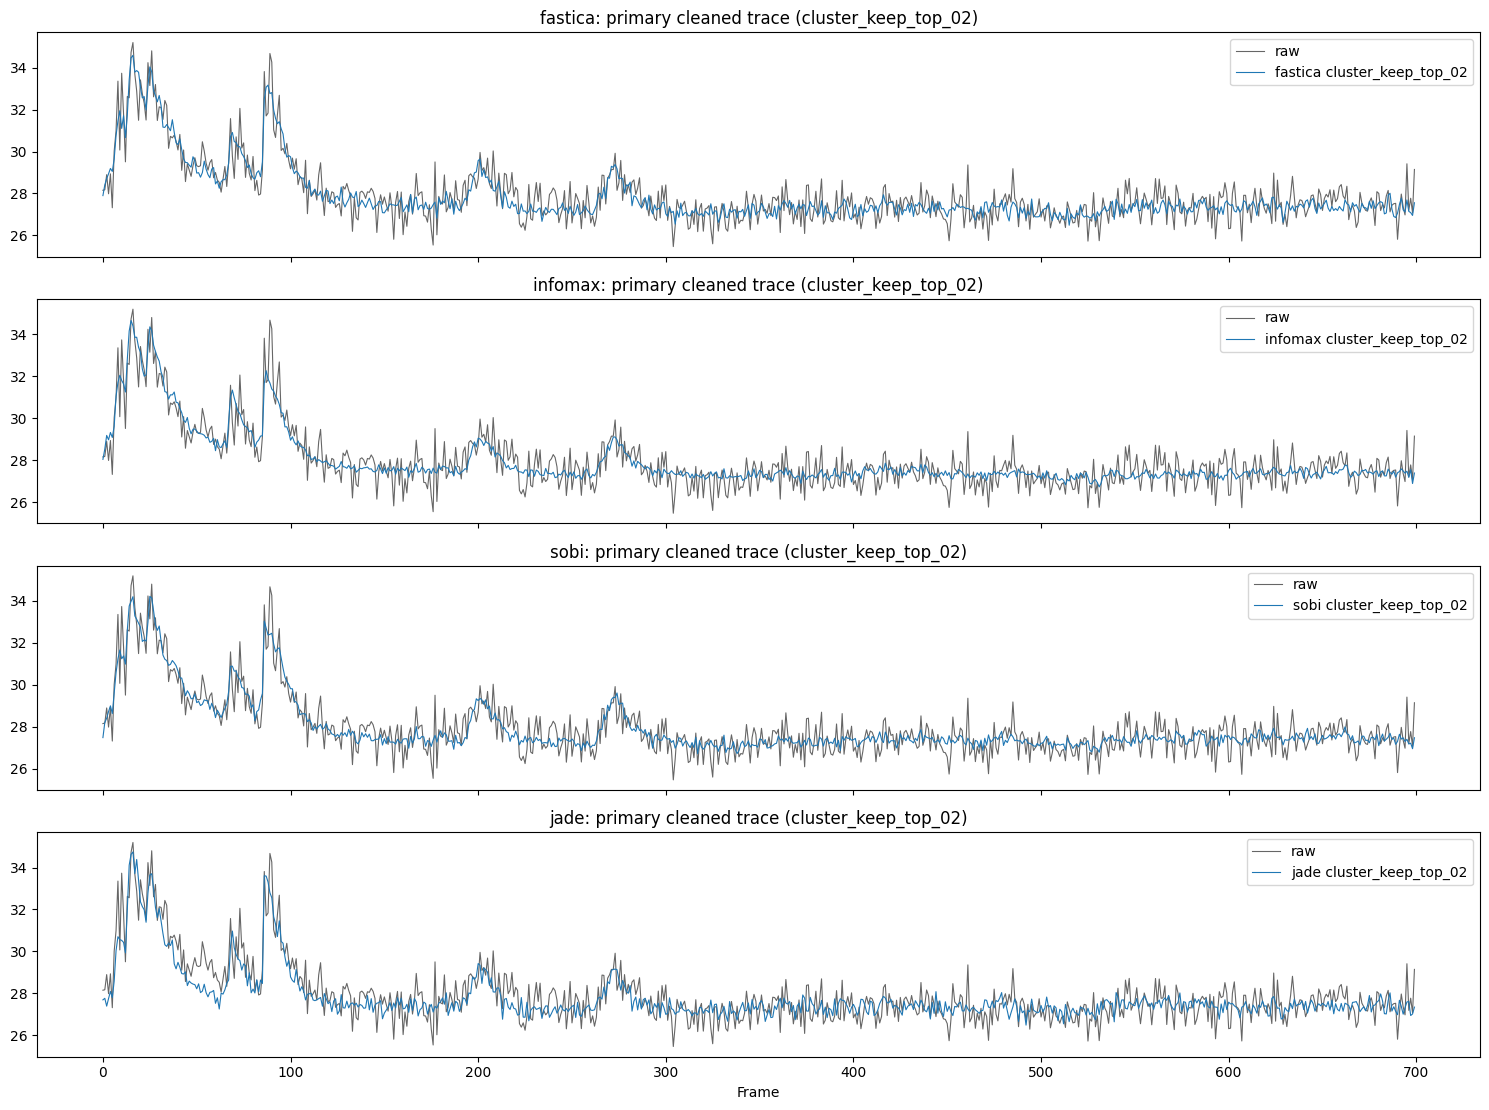

In [7]:
trace_variants = [TraceVariant("raw", dataset.trace_path, traces.T)]
for method, selections in cleaned_variants.items():
    for selection_id, cleaned in selections.items():
        variant_path = saved_paths_by_method.get(method, {}).get(selection_id, {}).get(
            "cleaned",
            Path(method) / selection_id,
        )
        trace_variants.append(TraceVariant(f"{method}/{selection_id}", variant_path, cleaned))

trace_preservation = summarize_trace_preservation(trace_variants, reference_name="raw")
trace_metrics_path = dataset_output_dir / "clustering_trace_preservation.csv"
if SAVE_OUTPUTS:
    trace_preservation.to_csv(trace_metrics_path, index=False)
    print(f"Trace metrics: {trace_metrics_path.relative_to(PROJECT_ROOT)}")
display(trace_preservation)

fig, axes = plt.subplots(len(cleaned_variants), 1, figsize=(15, 2.8 * len(cleaned_variants)), sharex=True)
axes = np.atleast_1d(axes)
neuron = 0
stop = min(700, traces.shape[1])
for ax, (method, selections) in zip(axes, cleaned_variants.items()):
    selection_id = primary_selection_by_method[method]
    cleaned = selections[selection_id]
    ax.plot(traces[neuron, :stop], label="raw", color="black", alpha=0.6, lw=0.8)
    ax.plot(cleaned[:stop, neuron], label=f"{method} {selection_id}", lw=0.8)
    ax.set_title(f"{method}: primary cleaned trace ({selection_id})")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Frame")
fig.tight_layout()
trace_comparison_path = figure_dir / f"cluster_cleaned_trace_comparison_{dataset.data_name}.png"
if SAVE_OUTPUTS:
    fig.savefig(trace_comparison_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved trace comparison: {trace_comparison_path.relative_to(PROJECT_ROOT)}")

metric_plot = trace_preservation[trace_preservation["variant"] != "raw"].copy()
if not metric_plot.empty and "nrmse" in metric_plot.columns:
    metric_plot = metric_plot.sort_values("nrmse").head(20)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(metric_plot))))
    ax.barh(metric_plot["variant"], metric_plot["nrmse"])
    ax.invert_yaxis()
    ax.set_xlabel("NRMSE vs raw")
    ax.set_title("Trace preservation by cleaned variant")
    fig.tight_layout()
    metrics_plot_path = figure_dir / f"cluster_cleaned_trace_metrics_{dataset.data_name}.png"
    if SAVE_OUTPUTS:
        fig.savefig(metrics_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
        print(f"Saved trace metric plot: {metrics_plot_path.relative_to(PROJECT_ROOT)}")


In [8]:
for method, selections in saved_paths_by_method.items():
    print(f"{method}: {results[method].output_dir.relative_to(PROJECT_ROOT)}")
    for selection_id, paths in selections.items():
        print(f"  {selection_id}")
        for label, artifact_path in paths.items():
            print(f"    {label}: {artifact_path.relative_to(PROJECT_ROOT)}")
if SAVE_OUTPUTS:
    print(f"cluster ranking: {cluster_ranking_path.relative_to(PROJECT_ROOT)}")
    print(f"component selections: {component_selection_path.relative_to(PROJECT_ROOT)}")
    print(f"IC quality: {ic_quality_path.relative_to(PROJECT_ROOT)}")
    print(f"selection summary: {selection_summary_path.relative_to(PROJECT_ROOT)}")
    print(f"trace metrics: {trace_metrics_path.relative_to(PROJECT_ROOT)}")
    print(f"figures: {figure_dir.relative_to(PROJECT_ROOT)}")


fastica: outputs/linear/v2a-RSNs/220119_F2_run11/fastica
  cluster_keep_top_01
    cleaned: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_01/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy
    cleaned_metadata: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_01/cleaned/metadata_cleaned_fastica_220119_F2_run11_fluorescence.json
    cluster_selection: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_01/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json
  cluster_keep_top_02
    cleaned: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_02/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy
    cleaned_metadata: outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned_variants/cluster_keep_top_02/cleaned/metadata_cleaned_fastica_220119_F2_run11_fluorescence.json
    cluster_selection: outputs/linear/v2a-RSNs/220119_F2_run11/f